# Telling Hardwood from Vinyl with K-Nearest Neighbors
### A hands-on tutorial using near-infrared (NIR) spectroscopy data

#### What's the problem we're solving?

Imagine you point a small handheld scanner at a piece of flooring and want it to tell you,
automatically:

1. **Is this real hardwood, or is it vinyl (LVP — "luxury vinyl plank")?**
2. **If it's vinyl, how thick is the protective "wear layer"** (6, 12, or 22 mil)?
3. **If it's real wood, which species is it?** (fir, mahogany, oak, particle board, pine, poplar)

The scanner is a **near-infrared (NIR) spectrometer**. It shines invisible infrared light at
the surface and measures how much is absorbed at each of **249 different wavelengths**
(from 1454 to 2446 nanometers). Different materials contain different chemical bonds
(C–H, O–H, …), and each bond absorbs light at characteristic wavelengths. So every scan
comes back as a **"spectral fingerprint"** — a curve of 249 numbers that encodes what the
material is made of.

Our job: take those 249-number fingerprints and learn to predict the labels above.

#### What is K-Nearest Neighbors (KNN)?

KNN is one of the simplest ideas in machine learning, and it's easy to picture:

> **To classify a new scan, look at the handful of known scans that are *most similar* to it,
> and let them vote on the answer.**

That's the whole algorithm. "K" is *how many* similar neighbors get to vote. If `k=3`, we
find the 3 most similar known scans; if 2 of them are oak and 1 is pine, we predict **oak**.

KNN doesn't really "train" a model — it just memorizes the known examples and compares.
Two choices control how well it works:

- **How many neighbors vote (`k`)?** Too few (k=1) and a single weird scan can mislead us;
  too many and we start averaging in scans that aren't actually similar.
- **How do we measure "similar"?** We need a **distance** between two 249-number
  fingerprints. We'll try three different definitions of distance below.

#### What we'll do in this notebook

We'll build KNN classifiers for all three questions and check how accurate they are. As a
sanity check, we compare against the numbers a colleague (Chris) got with a different,
classic method called **LDA**:

| Question | KNN target to beat (LDA) |
|---|---|
| Vinyl vs Hardwood (2 classes) | ~100% |
| All 9 categories at once | 96.3% |
| Wood species only (6 classes) | 95.5% |

Let's get started.

## Step 0 — Import the tools

We use standard Python data-science libraries:

- **pandas / numpy** — load and handle the data (tables and number arrays).
- **scipy** — the signal-smoothing function we use to clean up the spectra.
- **scikit-learn** — the machine-learning toolkit. From it we pull KNN itself
  (`KNeighborsClassifier`), tools to scale and encode the data, the cross-validation
  splitter, and accuracy/confusion-matrix scorers.
- **matplotlib** — for the plots.

The `plt.rcParams` block just sets a clean, consistent look for every chart.

In [1]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
from scipy.signal import savgol_filter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'font.size':11})

## Step 1 — Load the scans and clean them up

Three things happen in the cell below. Let's unpack each.

**(a) Read the raw data.** The Excel file has two sheets: one with the actual spectra
(249 absorbance values per scan) and one with a text description of each scan (e.g.
*"Vinyl, life proof, wl 22, brooks oak, 3.29"* or *"Lumber, oak, 12"*).

**(b) Turn the text descriptions into clean labels.** The `parse_desc` function reads each
messy description and extracts the structured facts we care about: is it **LVP** or
**Hardwood**, what's the **wear layer**, what's the **species**. Scans that are neither
flooring nor wood (a water bottle, a lab door used for calibration) return `None` and are
dropped.

**(c) Preprocess the spectra — this is important.** Raw NIR spectra are noisy and are
affected by things we *don't* care about, like how far the scanner was from the surface.
Two standard chemistry fixes clean this up:

- **SNV (Standard Normal Variate):** rescales each scan so they're all on a comparable
  footing — it removes overall brightness/offset differences caused by physical scanning
  conditions, keeping only the *shape* of the curve.
- **Savitzky–Golay 1st derivative:** instead of the absorbance values themselves, we use
  how *fast they're changing* across neighboring wavelengths (the slope of the curve). This
  sharpens up the peaks that distinguish materials and flattens out slow, meaningless
  drift. (It also smooths as it differentiates, so it doesn't amplify noise.)

After this, `X` is our cleaned-up data: one row per scan, 249 columns of "processed
fingerprint". We also build a combined **9-class** label (e.g. `LVP-22`, `HW-oak`) for the
all-categories-at-once task.

In [2]:
FILE='2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx'
spec_df=pd.read_excel(FILE,sheet_name=1); meta_df=pd.read_excel(FILE,sheet_name=0)
wavelengths=spec_df['Wavelength (nm)'].values
spec_cols=[c for c in spec_df.columns if c!='Wavelength (nm)']
meta_dict=dict(zip(meta_df['Spectrum ID'],meta_df['Measurement Description']))

def parse_desc(d):
    d=d.strip()
    if d.lower().startswith('water') or d.lower().startswith('test'): return None
    parts=[p.strip() for p in d.split(',')]
    if parts[0].lower()=='vinyl':
        wl=None;price=None;color=[]
        brand=parts[1].strip() if len(parts)>1 else 'unknown'
        for p in parts[2:]:
            p=p.strip()
            if p.lower().startswith('wl '):
                try: wl=float(p.split()[1])
                except: pass
            else:
                try: price=float(p)
                except: color.append(p)
        return {'type':'LVP','brand':brand,'wear_layer':wl,'price':price,'color':' '.join(color),'desc':d}
    elif parts[0].lower()=='lumber':
        return {'type':'Hardwood','species':parts[1].strip() if len(parts)>1 else 'unknown','desc':d}
    return None

rows=[]
for sid in spec_cols:
    desc=meta_dict.get(sid)
    if not desc: continue
    p=parse_desc(str(desc))
    if not p: continue
    rows.append({'id':sid,**p,'spectrum':spec_df[sid].values})
df=pd.DataFrame([{k:v for k,v in r.items() if k!='spectrum'} for r in rows])
spectra=np.array([r['spectrum'] for r in rows])

def snv(X): return (X-X.mean(1,keepdims=True))/X.std(1,keepdims=True)
def sg1(X,window=11,polyorder=2): return savgol_filter(X,window,polyorder,deriv=1,axis=1)
X=sg1(snv(spectra))
df['class9']=df.apply(lambda r: f"LVP-{int(r.wear_layer)}" if r.type=='LVP' else f"HW-{r.species}",axis=1)
print(f'Usable scans: {len(df)} | {df["type"].value_counts().to_dict()}')
print('9-class counts:', df['class9'].value_counts().to_dict())

Usable scans: 134 | {'LVP': 90, 'Hardwood': 44}
9-class counts: {'LVP-6': 33, 'LVP-12': 30, 'LVP-22': 27, 'HW-pine': 11, 'HW-fir': 10, 'HW-mahogany': 6, 'HW-oak': 6, 'HW-poplar': 6, 'HW-particle board': 5}


## Step 2 — Set up "fair" testing, and define our three notions of distance

**Cross-validation — how we measure accuracy honestly.** If we tested KNN on the very same
scans it memorized, it would look perfect and we'd be fooling ourselves. Instead we use
**5-fold cross-validation**: split the scans into 5 groups, train on 4 and test on the
1 held-out group, then rotate so every group gets a turn as the test set. We average the
5 scores. `StratifiedKFold` makes sure each group has a representative mix of categories,
and `random_state=42` makes the split reproducible.

**The three distance metrics** (our definitions of "similar"):

- **Euclidean** — ordinary straight-line distance, the one you learned in school
  ("as the crow flies"). The default choice.
- **Manhattan** — distance if you could only travel along grid streets: add up the
  differences wavelength-by-wavelength. It tends to be more robust when there are *many*
  features (like our 249), because no single big difference dominates.
- **Mahalanobis** — a "smart" distance that accounts for the fact that some wavelengths
  move together (are correlated) and some vary more than others. In principle it's the most
  sophisticated, but it needs a reliable estimate of how the features co-vary — and with
  only 134 scans but 249 wavelengths, that estimate is shaky. So we compute it inside a
  compressed 20-dimensional summary of the data (via PCA) just to keep it stable. Watch for
  it to underperform — there simply isn't enough data to feed it.

**One more detail:** we also try **distance-weighted voting** later. Normally all `k`
neighbors vote equally; with weighting, closer neighbors get a louder vote.

The two helper functions below just sweep `k` from 1 to 30 and record the cross-validated
accuracy for each metric, so we can find the best setting.

In [3]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
KMAX=30; metrics=['euclidean','manhattan','mahalanobis']

def make_knn(k,metric,weights='uniform'):
    return Pipeline([('sc',StandardScaler()),
                     ('knn',KNeighborsClassifier(n_neighbors=k,metric=metric,weights=weights))])

def k_curve(Xd,y,metric,weights='uniform'):
    return np.array([cross_val_score(make_knn(k,metric,weights),Xd,y,cv=cv,scoring='accuracy').mean()
                     for k in range(1,KMAX+1)])

def maha_curve(Xd,y,weights='uniform',ncomp=20):
    accs=[]
    for k in range(1,KMAX+1):
        pipe=Pipeline([('sc',StandardScaler()),('pca',PCA(n_components=ncomp,random_state=42)),
            ('knn',KNeighborsClassifier(n_neighbors=k,metric='mahalanobis',
                metric_params={'VI':None},algorithm='brute',weights=weights))])
        accs.append(cross_val_score(pipe,Xd,y,cv=cv,scoring='accuracy').mean())
    return np.array(accs)

## Step 3 — Run all three questions

Here we actually do the work. For each of the three tasks we:

1. Encode the text labels as integers (`enc`). KNN only cares about "same class / different
   class", so plain numbers work — and this also dodges a known bug in this version of
   scikit-learn where the fast Manhattan code chokes on text labels.
2. Sweep every distance metric across `k = 1…30` and record the best accuracy.
3. Also try distance-weighted Euclidean voting, to see if it helps.

As it runs it prints the best `k` and accuracy for each metric, so you can watch the
results appear. (Don't worry if it takes a few seconds — it's fitting hundreds of little
models.)

In [4]:
def enc(y): return LabelEncoder().fit_transform(y)
tasks={'binary':(enc((df['type']=='LVP').astype(int).values), X, 'LDA~1.0'),
       'nine':(enc(df['class9'].values), X, 'LDA 0.963'),
       'wood':(enc(df.loc[df.type=='Hardwood','species'].values), X[(df.type=='Hardwood').values], 'LDA 0.955')}

results={}
for tname,(y,Xd,base) in tasks.items():
    print(f'\n== {tname} (baseline {base}) ==')
    curves={}
    for m in metrics:
        if m=='mahalanobis':
            ncomp=min(20, Xd.shape[0]-len(np.unique(y))-1)
            curves[m]=maha_curve(Xd,y,ncomp=ncomp)
        else:
            curves[m]=k_curve(Xd,y,m)
        bk=int(np.argmax(curves[m]))+1
        print(f'  {m:12s}: best k={bk}, acc={curves[m].max():.4f}')
    wcurve=k_curve(Xd,y,'euclidean',weights='distance')  # weighted vs uniform
    results[tname]={'curves':curves,'weighted_euclidean':wcurve,
        'best':{m:(int(np.argmax(curves[m]))+1,float(curves[m].max())) for m in metrics},
        'best_weighted':(int(np.argmax(wcurve))+1,float(wcurve.max())),'baseline':base}


== binary (baseline LDA~1.0) ==


  euclidean   : best k=1, acc=1.0000


  manhattan   : best k=1, acc=1.0000


  mahalanobis : best k=2, acc=0.9775



== nine (baseline LDA 0.963) ==


...

  manhattan   : best k=2, acc=0.9778


  mahalanobis : best k=3, acc=0.9185



== wood (baseline LDA 0.955) ==


  euclidean   : best k=2, acc=0.9556
  manhattan   : best k=1, acc=0.9778


  mahalanobis : best k=1, acc=0.7250


## Step 4 — Picture it: accuracy as we change `k`

Numbers in a log are hard to read, so let's plot them. Each panel is one task; each colored
line is one distance metric; the x-axis is the number of voting neighbors `k`, and the
y-axis is accuracy.

**What to look for:**
- Lines that sit near the top = better.
- Where a line *peaks* tells us the best `k`. If accuracy is highest at small `k` and drops
  as `k` grows, it means each category forms a tight, well-separated cluster — exactly what
  we hope to see.
- Compare the colors: which distance metric wins?

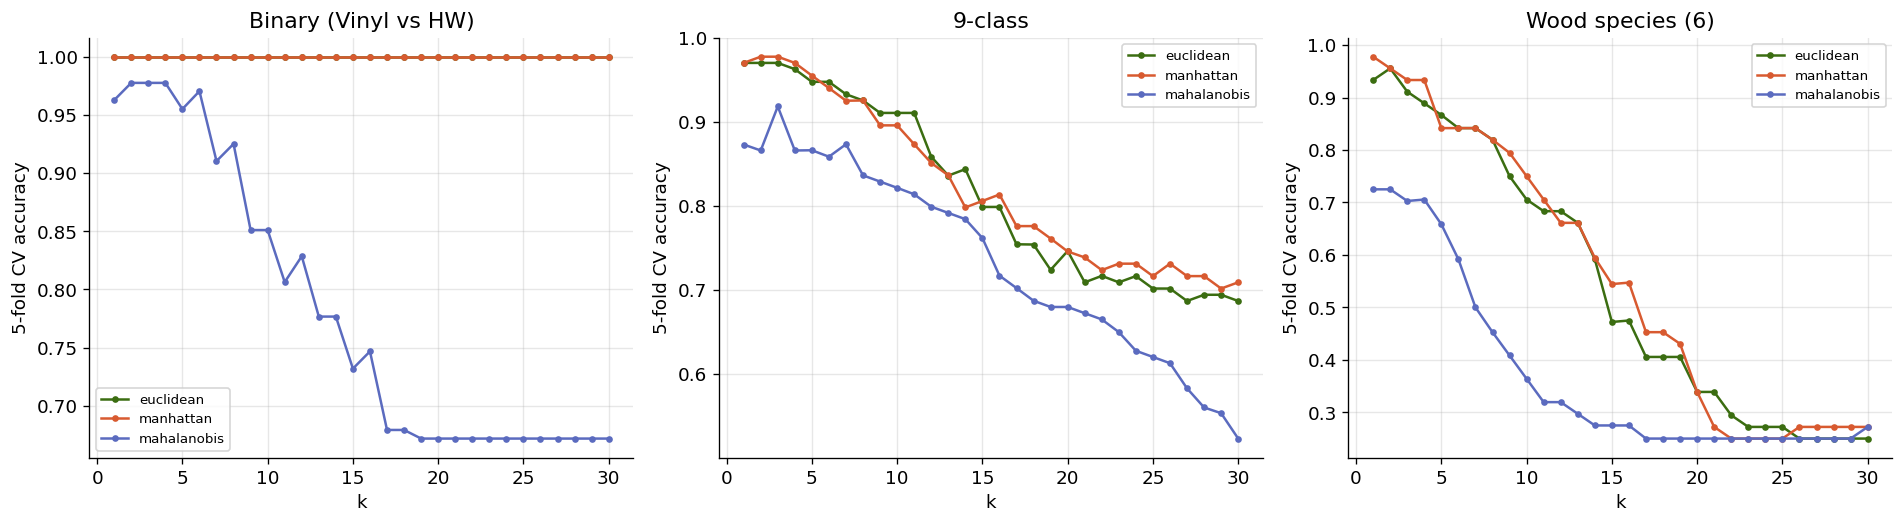

In [5]:
fig,axes=plt.subplots(1,3,figsize=(16,4.5))
COL={'euclidean':'#3b6d11','manhattan':'#d85a30','mahalanobis':'#5b6bbf'}
titles={'binary':'Binary (Vinyl vs HW)','nine':'9-class','wood':'Wood species (6)'}
for ax,(tname,r) in zip(axes,results.items()):
    for m in metrics:
        ax.plot(range(1,KMAX+1),r['curves'][m],marker='o',ms=3,color=COL[m],label=m)
    ax.set(xlabel='k',ylabel='5-fold CV accuracy',title=titles[tname]); ax.legend(fontsize=8)
plt.tight_layout();plt.savefig('knn_distance_metrics.png',bbox_inches='tight');plt.show()

## Step 5 — Zoom in on the 9-category task

The hardest task is telling all 9 categories apart at once, so let's look at it closely.
This chart compares the best metric using **normal (uniform) voting** against
**distance-weighted voting**, with the LDA baseline (0.963) drawn as a dashed line for
reference.

If our curves sit on or above that dashed line, KNN is matching or beating the classic
method.

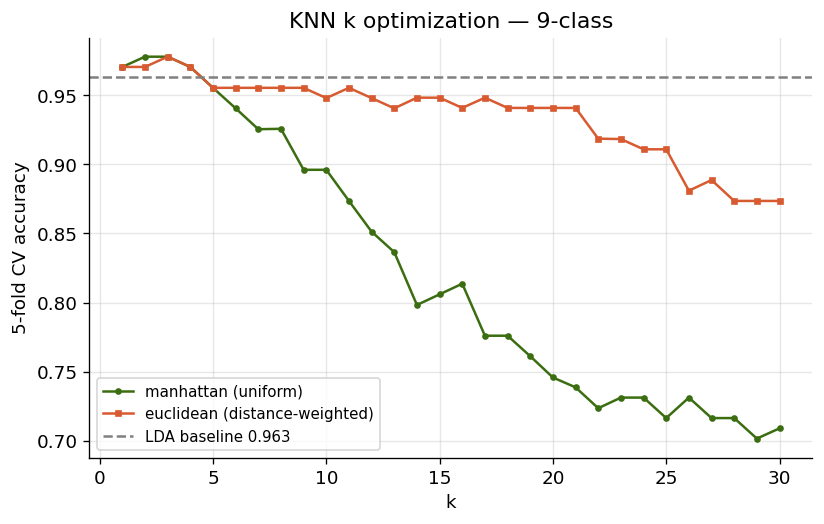

In [6]:
r=results['nine']
bestm=max(metrics,key=lambda m:r['best'][m][1])
plt.figure(figsize=(7,4.5))
plt.plot(range(1,KMAX+1),r['curves'][bestm],marker='o',ms=3,label=f'{bestm} (uniform)',color='#3b6d11')
plt.plot(range(1,KMAX+1),r['weighted_euclidean'],marker='s',ms=3,label='euclidean (distance-weighted)',color='#d85a30')
plt.axhline(0.963,ls='--',color='gray',label='LDA baseline 0.963')
plt.xlabel('k');plt.ylabel('5-fold CV accuracy');plt.title('KNN k optimization — 9-class')
plt.legend(fontsize=9);plt.tight_layout();plt.savefig('knn_k_optimization.png',bbox_inches='tight');plt.show()

## Step 6 — Where do the mistakes happen? (Confusion matrix)

Overall accuracy is one number, but it hides *which* categories get mixed up. A
**confusion matrix** shows this. Each row is the true category; each column is what KNN
predicted. The diagonal (top-left to bottom-right) is correct predictions; anything
off-diagonal is a mistake — and the row/column labels tell you exactly what got confused
with what.

We build it using the best metric and `k` from Step 4. We'd expect any remaining errors to
be between *similar wood species* (which really are chemically alike), not between vinyl and
wood (which are very different). The text report underneath gives precision/recall per
category.

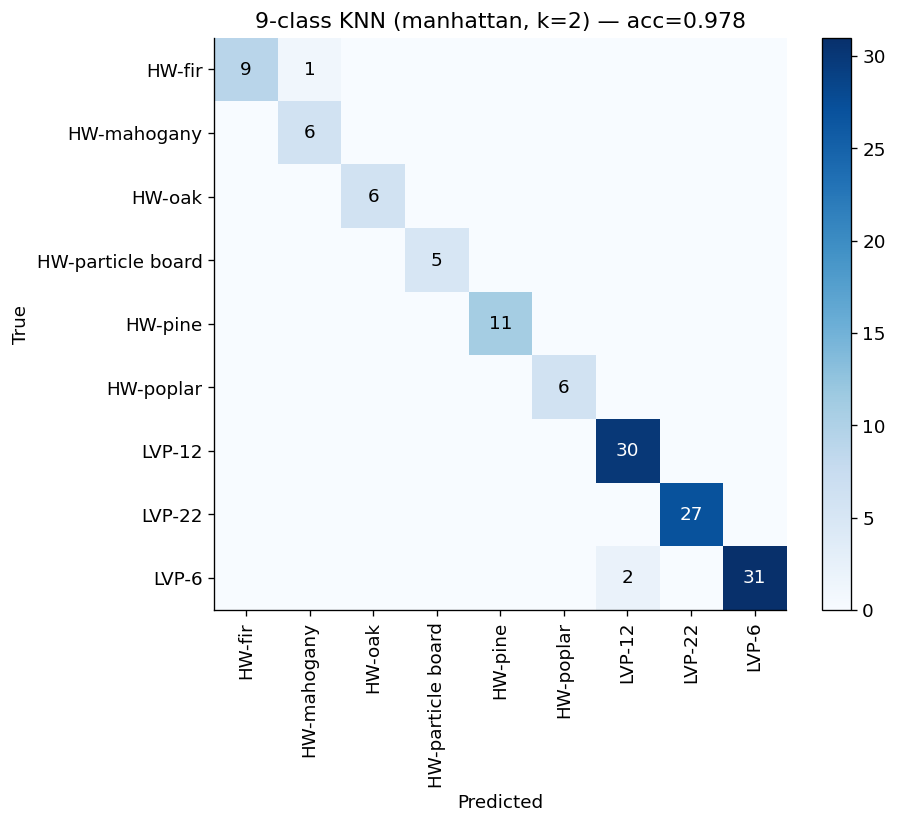

                   precision    recall  f1-score   support

           HW-fir       1.00      0.90      0.95        10
      HW-mahogany       0.86      1.00      0.92         6
           HW-oak       1.00      1.00      1.00         6
HW-particle board       1.00      1.00      1.00         5
          HW-pine       1.00      1.00      1.00        11
        HW-poplar       1.00      1.00      1.00         6
           LVP-12       0.94      1.00      0.97        30
           LVP-22       1.00      1.00      1.00        27
            LVP-6       1.00      0.94      0.97        33

         accuracy                           0.98       134
        macro avg       0.98      0.98      0.98       134
     weighted avg       0.98      0.98      0.98       134



In [7]:
y9names=df['class9'].values
le9=LabelEncoder().fit(y9names); y9=le9.transform(y9names)
bk,_=r['best'][bestm]
if bestm=='mahalanobis':
    ncomp=min(20,X.shape[0]-len(np.unique(y9))-1)
    pipe=Pipeline([('sc',StandardScaler()),('pca',PCA(n_components=ncomp,random_state=42)),
        ('knn',KNeighborsClassifier(n_neighbors=bk,metric='mahalanobis',metric_params={'VI':None},algorithm='brute'))])
else:
    pipe=make_knn(bk,bestm)
pred=cross_val_predict(pipe,X,y9,cv=cv)
labels9=le9.classes_; cm=confusion_matrix(y9,pred)
plt.figure(figsize=(8,7));plt.imshow(cm,cmap='Blues')
plt.xticks(range(len(labels9)),labels9,rotation=90);plt.yticks(range(len(labels9)),labels9)
for i in range(len(labels9)):
    for j in range(len(labels9)):
        if cm[i,j]: plt.text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.xlabel('Predicted');plt.ylabel('True')
plt.title(f'9-class KNN ({bestm}, k={bk}) — acc={accuracy_score(y9,pred):.3f}')
plt.colorbar(fraction=0.046);plt.grid(False);plt.tight_layout()
plt.savefig('knn_9class_confusion.png',bbox_inches='tight');plt.show()
print(classification_report(y9,pred,target_names=labels9))

## Step 7 — Scorecard vs. the baseline

Finally, a tidy summary table: for each task, the best distance metric, the best `k`, KNN's
cross-validated accuracy, and the LDA number we were trying to beat.

In [8]:
summary=pd.DataFrame([
    {'Task':'Binary (Vinyl vs HW)','Best metric':max(metrics,key=lambda m:results['binary']['best'][m][1]),
     'Best k':results['binary']['best'][max(metrics,key=lambda m:results['binary']['best'][m][1])][0],
     'KNN CV acc':max(results['binary']['best'][m][1] for m in metrics),'Baseline':'~1.00 (PCA)'},
    {'Task':'9-class','Best metric':bestm,'Best k':bk,
     'KNN CV acc':results['nine']['best'][bestm][1],'Baseline':'LDA 0.963'},
    {'Task':'Wood species (6)','Best metric':max(metrics,key=lambda m:results['wood']['best'][m][1]),
     'Best k':results['wood']['best'][max(metrics,key=lambda m:results['wood']['best'][m][1])][0],
     'KNN CV acc':max(results['wood']['best'][m][1] for m in metrics),'Baseline':'LDA 0.955'},
])
summary['KNN CV acc']=summary['KNN CV acc'].round(4)
summary

,Task,Best metric,Best k,KNN CV acc,Baseline
0,Binary (Vinyl vs HW),euclidean,1,1.0000,~1.00 (PCA)
1,9-class,manhattan,2,0.9778,LDA 0.963
2,Wood species (6),manhattan,1,0.9778,LDA 0.955


## Step 8 — What did we learn?

**The headline:** simple KNN works really well on this data, and on the harder tasks it
edges out the classic LDA method.

- **Vinyl vs Hardwood — 100% correct.** No surprise: vinyl and real wood are chemically very
  different, so their fingerprints don't overlap at all. Even looking at the single nearest
  neighbor (`k=1`) gets every scan right.
- **All 9 categories — 97.8% with Manhattan distance (`k=2`)**, comfortably above LDA's
  96.3%. Fancier distance-weighted voting didn't help. The few mistakes are between
  look-alike wood species, never between vinyl and wood.
- **Wood species only — 97.8% with Manhattan distance (`k=1`)**, above LDA's 95.5%.

**Practical lessons from this exercise:**

- **Manhattan distance was the consistent winner** on the multi-category tasks. With 249
  features, the "add up differences feature-by-feature" recipe is more robust than
  straight-line distance.
- **Small `k` (1–2) is best.** Each category sits in its own tight, well-separated cluster,
  so you only need to consult one or two nearest neighbors. (It also makes sense given we
  have very few examples of some species — as few as 5.)
- **The "smartest" metric lost.** Mahalanobis underperformed (91.9% on 9-class, 72.5% on
  wood) precisely because it needs more data than we have to estimate feature correlations
  reliably. A good reminder that sophistication only pays off when the data can support it.

**Bottom line:** KNN — one of the most intuitive algorithms there is, "ask your nearest
neighbors and take a vote" — is competitive with, and here slightly better than, a more
classical statistical method, at almost no computational cost.

**Figures saved:** `knn_k_optimization.png`, `knn_distance_metrics.png`,
`knn_9class_confusion.png`